# Классификация сортов ириса

> Задача взята из книги А.Мюллер, С.Гвидо "Введение в машинное обучение с помощью Python".

Ботаник-любитель собрал цветки ирисов и хочет классифицировать их.
Он измерил в сантиметрах следующие характеристики ирисов: длину и ширину лепестков, а также длину и ширину чашелистиков.

```{figure} images/iris-1.png
```

Кроме того, у него есть измерения этих же характеристик ирисов, которые ранее позволили опытному эксперту отнести их к сортам:
* setosa (ирис щетинистый);
* versicolor (ирис разноцветный);
* virginica (ириз виргинский).

Наша цель -- построить модель машинного обучения, которая сможет обучиться на основе характеристик ирисов, уже классифицированных по сортам, и затем предскажет сорт для нового цветка ириса.

```{figure} images/irissetosa.jpg
:scale: 30%

Ирис щетинистый
```

```{figure} images/irisversicolor.jpg
:scale: 30%

Ирис разноцветный
```

```{figure} images/irisvirginica.jpg
:scale: 30%

Ирис виргинский
```


Поскольку у нас есть примеры, по которых мы уже знаем правильные сорта ириса, решаемая задача является **задачей обучения с учителем**.
В этой задаче нам нужно спрогнозировать один из сортов ириса.
Это пример **задачи классификации**.
Возможные ответы (различные сорта ириса) называются **классами**.
Каждый ирис в наборе данных принадлежит к одному из трех классов, таким образом решаемая задача является задачей **трехклассовой классификации**.

Ответом для отдельной **точки данных** (ириса) является тот или иной сорт этого цветка.
Cорт, к которому принадлежит цветок (конкретная точка данных), называется **меткой**.

## Загружаем данные

Данные, которые мы будем использовать для этого примера, – это набор данных `Iris`, классический набор данных в машинном обучении и статистике.
Он уже включен в модуль `datasets` библиотеки `scikit-learn`.
Мы можем загрузить его, вызвав функцию `load_iris`.

In [15]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

Объект `iris_dataset`, возвращаемый `load_iris`, является объектом `Bunch`, который очень похож на словарь.
Он содержит ключи и значения:

In [16]:
print("Ключи iris_dataset:")
print(iris_dataset.keys())

Ключи iris_dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Ключи объекта `iris_dataset`:
* `DESCR` -- краткое описание набора данных;
* `target_names` -- сорта цветков, которые мы хотим предсказать;
* `feature_names` -- описание каждого признака;
* `data` -- массив с количественными измерениями длины и ширины лепестков и чашелистиков;
* `target` -- сорта уже измеренных цветков;
* `frame`
* `filename`
* `data_module`

In [17]:
print(iris_dataset['DESCR'][:193])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 


In [18]:
print(iris_dataset['target_names'])

['setosa' 'versicolor' 'virginica']


In [19]:
print(iris_dataset['feature_names'])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [20]:
print(type(iris_dataset['data']))
print(iris_dataset['data'].shape)
print("Первые пять строк массива data")
print(iris_dataset['data'][:5])

<class 'numpy.ndarray'>
(150, 4)
Первые пять строк массива data
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


Массив `data` содержит измерения для 150 различных цветков по 4 признакам.
В машинном обучении отдельные элементы называются примерами (samples), а их свойства -- характеристиками или признаками (feature).
Форма (shape) массива данных определяется количеством примеров, умноженным на количество признаков.
Это является общепринятым соглашением в scikit-learn, и ваши данные всегда будут представлены в этой форме.

```{figure} images/image-1.png
```

In [21]:
print(type(iris_dataset['target']))
print(iris_dataset['target'].shape)
print(iris_dataset['target'])

<class 'numpy.ndarray'>
(150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


```{figure} images/image-2.png
```

## Обучающий и тестовый наборы

**Обучающий набор** -- данные, на которых будет обучена модель.
**Контрольный набор** -- новые размеченные данные, которые модель не видела раньше.

В библиотеке `scikit-learn` есть функция `train_test_split`, которая перемешивает набор данных и разбивает его на две части.
Эта функция отбирает в обучающий набор 75% строк данных с соответствующими метками.
Оставшиеся 25% данных с метками объявляются тестовым набором. 
```{note}
Использование тестового набора, содержащего 25% данных, является хорошим правилом. 
```
```{note}
Мы перемешиваем наши данные, чтобы тестовые данные содержали все три класса.
```

```{figure} images/image-3.png
```
[Ссылка](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) на документацию.

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'],
    iris_dataset['target'],
    random_state=0)

Чтобы в точности повторно воспроизвести полученный результат, мы воспользуемся генератором псевдослучайных чисел с фиксированным стартовым значением, которое задается с помощью параметра `random_state`.
Это позволит сделать результат воспроизводим, поэтому вышеприведенный программный код будет генерировать один и тот же результат.
```{note}
Всегда следует задавать `random_state` при использовании рандомизированных процедур.
```

In [23]:
print(X_train.shape)
print(y_train.shape)

(112, 4)
(112,)


In [24]:
print(X_test.shape)
print(y_test.shape)

(38, 4)
(38,)


## Исследуем исходные данные

Исследование данных – это хороший способ обнаружить аномалии и особенности.
Например, вполне возможно, что некоторые из ваших ирисов измерены в дюймах, а не в сантиметрах.
В реальном мире нестыковки в данных и неожиданности очень распространены.

*Диаграмма рассеяния* (точечная диаграмма, диаграмма разброса) -- это график, который показывает связь между двумя числовыми величинами на координатной плоскости.
```{figure} images/scatter_diagram.png
```
Диаграмма позволяет разместить на графике только два (или, возможно, три) признака одновременно.
Таким образом, трудно разместить на графике наборы данных с более чем тремя признаками.
Один из способов решения этой проблемы -- построить матрицу диаграмм рассеяния (парные диаграммы рассеяния), на которых будут изображены все возможные пары признаков.

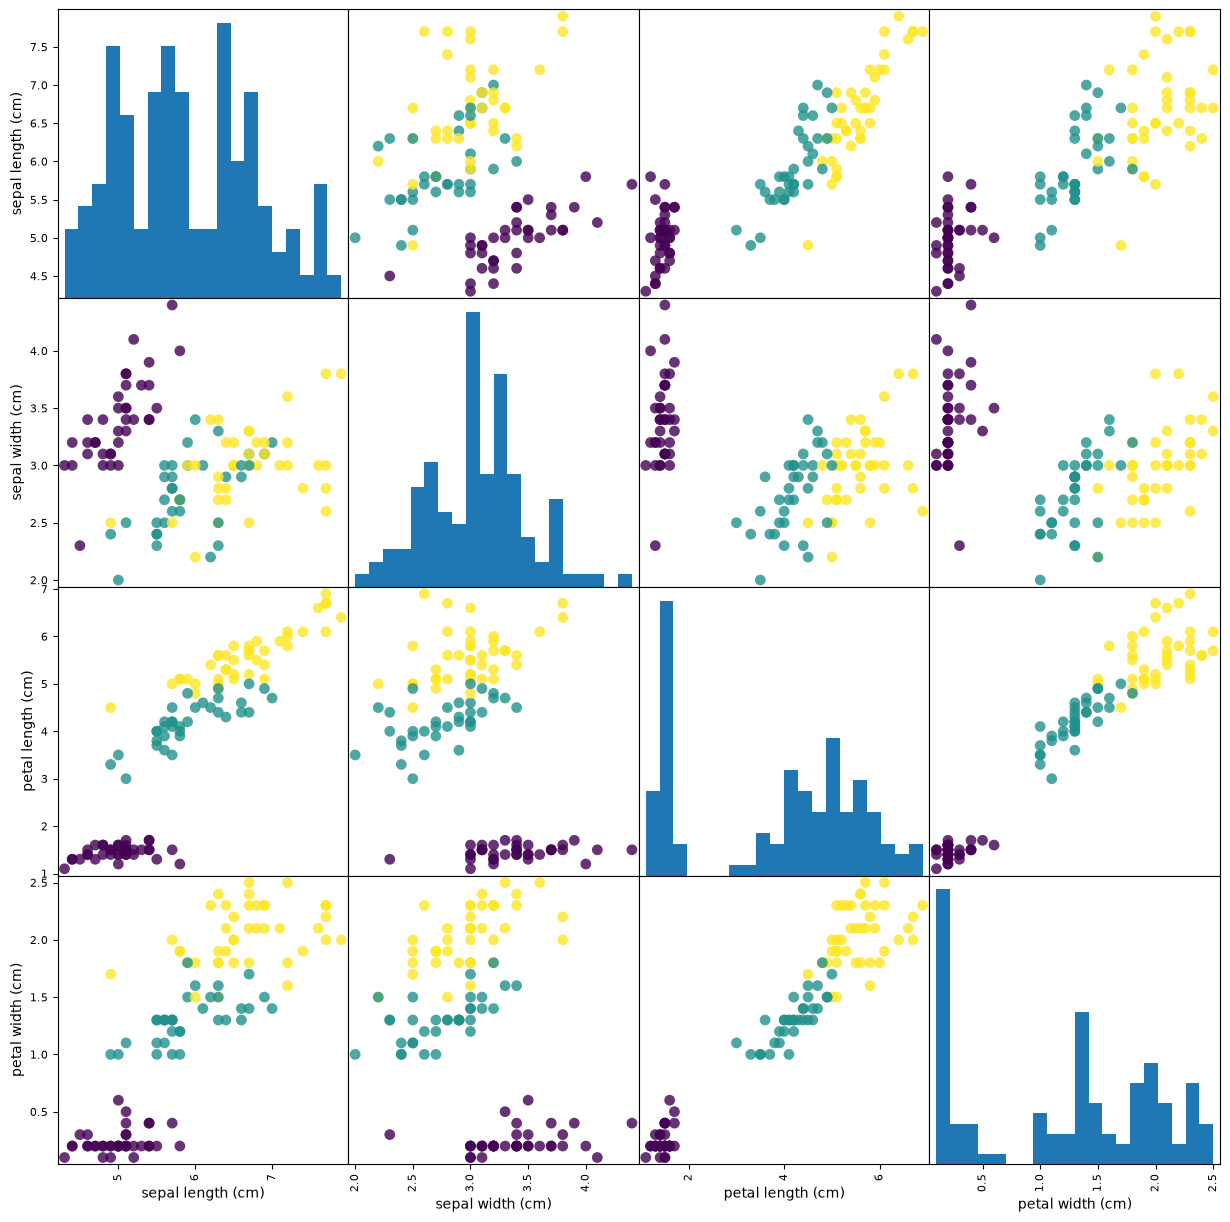

In [25]:
import pandas
# создаем dataframe из данных в массиве X_train
# маркируем столбцы, используя строки в iris_dataset.feature_names
iris_dataframe = pandas.DataFrame(X_train, columns=iris_dataset.feature_names)
# создаем матрицу рассеяния из dataframe, цвет точек задаем с помощью y_train
grr = pandas.plotting.scatter_matrix(
    iris_dataframe,
    c=y_train,
    figsize=(15, 15),
    marker='o',
    hist_kwds={'bins': 20},
    s=60,
    alpha=.8)

По графику можно судить, что, похоже, измерения позволяют относительно хорошо разделить три класса.
Это означает, что модель машинного обучения, вероятно, сможет научиться разделять их.

## Построение модели

Теперь мы можем начать строить реальную модель машинного обучения.
В библиотеке scikit-learn имеется довольно много алгоритмов классификации, которые мы могли бы использовать для построения модели.
В данном примере мы будем использовать классификатор на основе **метода k ближайших соседей**, который легко интерпретировать.
Построение этой модели заключается лишь в запоминании обучающего набора.
Для того, чтобы сделать прогноз для новой точки данных, алгоритм находит точку в обучающем наборе, которая находится ближе всего к новой точке.
Затем он присваивает метку, принадлежащую этой точке обучающего набора, новой точке данных.

k в методе k ближайших соседей означает, что вместо того, чтобы использовать лишь ближайшего соседа новой точки данных, мы в ходе обучения можем рассмотреть любое фиксированное число (k) соседей (например, рассмотреть ближайшие три или пять соседей).
Тогда мы можем сделать прогноз для точки данных, используя класс, которому принадлежит большинство ее соседей.

В scikit-learn все модели машинного обучения реализованы в собственных классах, называемых классами `Estimator`.
Алгоритм классификации на основе метода k ближайших соседей реализован в классификаторе `KNeighborsClassifier` модуля `neighbors`.
Прежде чем использовать эту модель, нам нужно создать объект-экземпляр класса.
Это произойдет, когда мы зададим параметры модели.
Самым важным параметром KNeighborsClassifier является количество соседей, которые мы установим равным 1.

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

Объект `knn` включает в себя алгоритм, который будет использоваться для построения модели на обучающих данных, а также алгоритм, который сгенерирует прогнозы для новых точек данных.
Он также будет содержать информацию, которую алгоритм извлек из обучающих данных.

Для построения модели на обучающем наборе, мы вызываем метод `fit` объекта `knn`, который принимает в качестве аргументов массив `NumPy` `X_train`, содержащий обучающие данные, и массив `NumPy` `y_train`, соответствующий обучающим меткам.
Метод `fit` возвращает сам объект `knn` (и изменяет его), таким образом, мы получаем строковое представление нашего классификатора.
Оно показывает нам, какие параметры были использованы при создании модели.

In [27]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Получение прогнозов

Теперь мы можем получить прогнозы, применив эту модель к новым данным, по которым мы еще не знаем правильные метки.
Представьте, что мы нашли в дикой природе ирис с длиной чашелистика 5 см, шириной чашелистика 2.9 см, длиной лепестка 1 см и шириной лепестка 0.2 см.
К какому сорту ириса нужно отнести этот цветок?
Мы можем поместить эти данные в массив `NumPy`.

Обратите внимание, что мы записали измерения по одному цветку в двумерный массив NumPy, поскольку `scikit-learn` работает с двумерными массивами данных.
Чтобы сделать прогноз, мы вызываем метод `predict` объекта `knn`.

In [28]:
import numpy as np
X_new = np.array([[5, 2.9, 1, 0.2]])
prediction = knn.predict(X_new)
print("Прогноз:")
print(prediction)
print("Спрогнозированная метка:");
print(iris_dataset['target_names'][prediction]);

Прогноз:
[0]
Спрогнозированная метка:
['setosa']


Наша модель предсказывает, что этот новый цветок ириса принадлежит к классу 0, что означает сорт setosa.
Но как узнать, можем ли мы доверять нашей модели?
Правильный сорт ириса для этого примера нам неизвестен, а ведь именно получение правильных прогнозов и является главной задачей построения модели!

## Оценка качества модели

Это тот самый момент, когда нам понадобится созданный ранее тестовый набор.
Эти данные не использовались для построения модели, но мы знаем правильные сорта для каждого ириса в тестовом наборе.
Таким образом, мы можем сделать прогноз для каждого ириса в тестовом наборе и сравнить его с фактической меткой (уже известным сортом).
Мы можем оценить качество модели, вычислив **долю правильных ответов** (accuracy) -- процент цветов, для которых модель правильно спрогнозировала сорта

In [29]:
y_pred = knn.predict(X_test)
print("Прогнозы для тестового набора:")
print(y_pred)
print("Правильность на тестовом наборе:")
print(np.mean(y_pred == y_test))

Прогнозы для тестового набора:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Правильность на тестовом наборе:
0.9736842105263158


Кроме того, мы можем использовать метод `score` объекта `knn`, который вычисляет правильность модели для тестового набора.

In [30]:
print("Правильность на тестовом наборе:")
print(knn.score(X_test, y_test))

Правильность на тестовом наборе:
0.9736842105263158


Правильность этой модели для тестового набора составляет около 0.97, что означает, что мы дали правильный прогноз для 97% ирисов в тестовом наборе.
При некоторых математических допущениях, это означает, что мы можем ожидать, что наша модель в 97% случаев даст правильный прогноз для новых ирисов.
Для нашего ботаника-любителя этот высокий уровень правильности означает, что наша модель может быть достаточно надежной в использовании.

## Итог

Мы сформулировали задачу классификации ирисов на основе проведенных измерений характеристик цветков.
Мы использовали набор данных, в котором эксперт уже предварительно классифицировал ирисы для построения модели, таким образом, мы решали задачу обучения с учителем.
Было три возможных сорта ирисов, что делало нашу задачу задачей **3-классовой классификации**.
В задаче классификации возможные сорта ирисов называются классами а сами названия сортов -- **метками**.

Набор данных `Iris` состоит из двух массивов `NumPy`: один содержит данные и в `scikit-learn` обозначается как `X`, другой содержит правильные или нужные ответы и обозначается как `y`.
Массив `Х` представляет собой двумерный массив признаков, в котором одна строка соответствует одной точке данных, а один столбец – одному признаку.
Массив `у` представляет собой одномерный массив, который для каждого примера содержит метку класса, целое число от 0 до 2.

Мы разделили наш набор данных на *обучающий набор*, чтобы построить нашу модель, а также *тестовый набор*, чтобы оценить, насколько хорошо наша модель будет классифицировать новые, ранее незнакомые ей данные.

Мы выбрали **алгоритм классификации k ближайших соседей**, который генерирует прогноз для новой точки данных, рассматривая ее ближайшего соседа(ей) в обучающем наборе.
Все это реализовано в классе `KNeighborsClassifier`, который содержит алгоритм, строящий модель, а также алгоритм, который дает прогнозы, используя построенную модель.
Мы создали объект-экземпляр класса, задав параметры.
Затем мы построили модель, вызвав метод `fit` и передав обучающие данные (`X_train`) и обучающие ответы (`y_train`) в качестве параметров.
Мы оценили качество модели с использованием метода `score`, который вычисляет правильность модели.
Мы применили метод `score` к тестовым данным и тестовым ответам и обнаружили, что наша модель демонстрирует правильность около 97%.
Это означает, что модель выдает правильные прогнозы для 97% наблюдений тестового набора.